A notebook to parse the data from various NER datasets in CC: [ClimateIE](https://github.com/Jo-Pan/ClimateIE/tree/main) corpus, [Climate-Change-NER](https://huggingface.co/datasets/ibm-research/Climate-Change-NER), ...

## Data and Libraries

In [2]:
import json
import os
import json
from typing import Dict, Set, List

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from seqeval.metrics.sequence_labeling import get_entities

from collections import defaultdict, OrderedDict

### Load BiodivNER

In [3]:
# Use uppercase for constants as per Python conventions.
DATA_DIRECTORY = "DATA/BiodivNER/"
# A set of expected entity labels.
EXPECTED_LABELS = {
    'Quality', 'Phenomena', 'Organism',
    'Matter', 'Location', 'Environment'
}

# --- Initialization ---
# Prepare the output dictionary with an empty set for each label.
entities_by_label_BIODIVNER = {label: set() for label in EXPECTED_LABELS}

# --- Main Logic: Parse CSV Files ---
try:
    # 1. Get a list of all files in the directory that end with .csv
    csv_files = [f for f in os.listdir(DATA_DIRECTORY) if f.endswith('.csv')]
except FileNotFoundError:
    print(f"Error: The directory '{DATA_DIRECTORY}' was not found.")
    csv_files = []

# 2. Process each CSV file (train.csv, dev.csv, test.csv)
for file_name in csv_files:
    file_path = os.path.join(DATA_DIRECTORY, file_name)
    print(f"\nProcessing file: '{file_path}'...")
    
    try:
        # 3. Read the CSV file into a pandas DataFrame.
        df = pd.read_csv(file_path, encoding='latin1') # 'latin1' is common for such datasets
        
        # 4. Clean the data: Drop any rows where 'Word' or 'Tag' is missing.
        df.dropna(subset=['Word', 'Tag'], inplace=True)

        # 5. Extract all tokens and tags into two master lists for the entire file.
        all_tokens_in_file = df['Word'].tolist()
        all_tags_in_file = df['Tag'].tolist()

        # 6. Use seqeval to extract entities from the complete tag sequence.
        print(f"Found {len(all_tokens_in_file)} tokens. Extracting entities...")
        extracted_entities = get_entities(all_tags_in_file)
        
        # 7. Reconstruct the entity text and add it to our dictionary.
        for entity_label, start_idx, end_idx in extracted_entities:
            # Check if the extracted label is one of the types we are looking for.
            if entity_label in entities_by_label_BIODIVNER:
                # Join the tokens to form the full entity string.
                entity_text = " ".join(all_tokens_in_file[start_idx : end_idx + 1])
                
                # Add the correctly parsed entity to the corresponding set.
                entities_by_label_BIODIVNER[entity_label].add(entity_text)
                
    except Exception as e:
        print(f"  Could not process file '{file_name}'. Error: {e}")

print("\n--- Parsing Complete ---")

# --- Verification: Print the results ---
for label, entity_set in entities_by_label_BIODIVNER.items():
    count = len(entity_set)
    if count > 0:
        example_list = sorted(list(entity_set))
        print(f"\n✅ Found {count} unique entities for '{label}':")
        # Show a sample of up to 10 entities.
        print(example_list[:10])


Processing file: 'DATA/BiodivNER/test.csv'...
Found 11673 tokens. Extracting entities...

Processing file: 'DATA/BiodivNER/dev.csv'...
Found 10692 tokens. Extracting entities...

Processing file: 'DATA/BiodivNER/train.csv'...
Found 79748 tokens. Extracting entities...

--- Parsing Complete ---

✅ Found 698 unique entities for 'Quality':
['ALTITUDE', 'AREA', 'Above-ground biomass', 'Absolute crown displacement', 'Abundance', 'Abundance/Size', 'Age', 'Age class', 'Altitude', 'Aluminum content']

✅ Found 81 unique entities for 'Location':
['Aegean Sea', 'Alboran Sea', 'Austin', 'Australia', 'Bootless Bay', 'Chaoyang District Beijing China', 'China', 'Country', 'County', 'Deutscher Platz 5e Leipzig']

✅ Found 207 unique entities for 'Phenomena':
['Agricultural methane emissions', 'Agricultural nitrous oxide', 'Agricultural nitrous oxide emissions', 'Aquaculture', 'Autumn', 'Biological activity', 'Biological invasions', 'CO2 emissions', 'Climate', 'Climate Change']

✅ Found 328 unique enti

### Load Climate-Change-NER

In [4]:
# --- Configuration ---
HF_DIRECTORY = "ibm-research/Climate-Change-NER"
LABELS = {
    "climate-assets", "climate-datasets", "climate-greenhouse-gases",     
    "climate-hazards", "climate-impacts", "climate-mitigations",     
    "climate-models", "climate-nature", "climate-observations",     
    "climate-organisms", "climate-organizations", "climate-problem-origins",
    "climate-properties"
}

# --- Initialization ---
print(f"Loading dataset '{HF_DIRECTORY}'...")
# The 'text' feature in this dataset version is what we need.
ds = load_dataset(HF_DIRECTORY, "1.0.0") 

entities_by_label_IBMCCNER = {label: set() for label in LABELS}

# --- Main Logic: Process Each Split as a Single Sequence ---
# 1. Process each split in the dataset (train, validation, test)
for split in ds.keys():
    print(f"\nProcessing '{split}' split...")
    
    # We will build two master lists for the entire split
    all_tokens_in_split = []
    all_tags_in_split = []
    
    # 2. Iterate through each line (row) provided by the dataset iterator
    for row in ds[split]:
        line = row['text']
        
        # Ignore DOCSTART metadata lines and empty lines
        if line.strip().startswith('-DOCSTART-') or not line.strip():
            continue
        
        # 3. Parse the 'token tag' string from the 'text' field
        parts = line.rsplit(' ', 1)
        if len(parts) == 2:
            token, tag = parts
            all_tokens_in_split.append(token)
            all_tags_in_split.append(tag)
            
    # 4. After processing all lines, we have the full sequence for the split.
    #    Now, use seqeval to extract entities from this complete sequence.
    print(f"Found {len(all_tokens_in_split)} tokens in the split. Extracting entities...")
    extracted_entities = get_entities(all_tags_in_split)
    
    # 5. Reconstruct the entity text and add it to our dictionary
    for entity_label, start_idx, end_idx in extracted_entities:
        if entity_label in entities_by_label_IBMCCNER:
            # Join the tokens to form the full entity string
            entity_text = " ".join(all_tokens_in_split[start_idx : end_idx + 1])
            
            # Add the correctly parsed, multi-token entity to the set
            entities_by_label_IBMCCNER[entity_label].add(entity_text)

Loading dataset 'ibm-research/Climate-Change-NER'...

Processing 'train' split...
Found 31649 tokens in the split. Extracting entities...

Processing 'validation' split...
Found 6366 tokens in the split. Extracting entities...

Processing 'test' split...
Found 5775 tokens in the split. Extracting entities...


### Load ClimateIE

In [5]:
# ClimateIE

# Use uppercase for constants as per Python conventions.
DATA_DIRECTORY = "DATA/ClimateIE/human_corpus/"
# A set of expected entity labels.
EXPECTED_LABELS = {
    'experiment', 'instrument', 'location',
    'model', 'natural hazard', 'ocean circulation',
    'teleconnection', 'variable', 'weather event',
    'provider', 'project', 'event'
}

# --- Main Logic ---
# Get a list of all files in the specified directory.
# Added a check to ensure we only process .json files.
try:
    file_names = [f for f in os.listdir(DATA_DIRECTORY) if f.endswith('.json')]
except FileNotFoundError:
    print(f"Error: The directory '{DATA_DIRECTORY}' was not found.")
    file_names = []

# Initialize a dictionary to hold a set for each label.
# Using a dictionary comprehension is the correct and pythonic way.
# Using a set() will ensure that each entity substring is stored only once per category.
entities_by_label_ClimateIE = {label: set() for label in EXPECTED_LABELS}

# Process each file.
for file_name in file_names:
    # Use os.path.join for safe path construction across different operating systems.
    file_path = os.path.join(DATA_DIRECTORY, file_name)
    
    with open(file_path, "r", encoding="utf-8") as f:
        document = json.load(f)

    # Safely get the entities dictionary.
    entities = document.get("entities", {})
    
    # Iterate through each entity's data in the "entities" dictionary.
    for entity_data in entities.values():
        label = entity_data.get("label")
        substring = entity_data.get("substring")
        
        # Check if the label is one we expect and add the substring to the corresponding set.
        if label in entities_by_label_ClimateIE:
            entities_by_label_ClimateIE[label].add(substring)

### Load CWED4ETA

In [6]:

def parse_label_studio_entities(file_path: str, predefined_labels: List[str]) -> Dict[str, Set[str]]:
    """
    Loads a Label Studio JSON export and parses all annotated entities,
    categorizing them into sets based on a predefined list of labels.

    Args:
        file_path (str): The path to the Label Studio JSON export file.
        predefined_labels (List[str]): A list of the entity types to look for and categorize.

    Returns:
        Dict[str, Set[str]]: A dictionary where keys are the predefined labels and
                             values are sets of unique entity strings found for that label.
    """
    # Initialize a dictionary with an empty set for each predefined label.
    # This ensures all categories are present in the output, even if none are found.
    entities_by_type = {label: set() for label in predefined_labels}
    
    # Use a set for predefined_labels for faster lookups (O(1) average time complexity).
    predefined_labels_set = set(predefined_labels)

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file was not found at '{file_path}'")
        return {}
    except json.JSONDecodeError:
        print(f"Error: The file at '{file_path}' is not a valid JSON file.")
        return {}

    # A Label Studio export is a list of "tasks" (the items that were annotated).
    for task in data:
        # Each task can have multiple annotations; we'll check the first one.
        if not task.get('annotations'):
            continue
        
        # The actual labeled spans are in the 'result' list.
        annotations = task['annotations'][0].get('result', [])
        
        for annotation in annotations:
            # We are only interested in text labels.
            if annotation.get('type') != 'labels':
                continue
            
            value = annotation.get('value', {})
            
            # Ensure the annotation has the expected structure ('text' and 'labels' keys).
            if 'text' in value and 'labels' in value and value['labels']:
                entity_text = value['text']
                # The label is the first (and usually only) item in the 'labels' list.
                entity_label = value['labels'][0]
                
                # If the found label is one of our predefined types, add the entity text.
                if entity_label in predefined_labels_set:
                    entities_by_type[entity_label].add(entity_text)

    return entities_by_type

# --- Configuration ---

# 1. Define the path to your Label Studio JSON file.
#    Replace this with the actual path to your file.
LABEL_STUDIO_FILE_PATH = 'DATA/LABEL_STUDIO/project-6-at-2025-10-15-11-04-1fe53515.json' 

# 2. Define your complete list of entity types (predefined classes).
ENTITY_TYPES = [
    'Ecosystem', 'Energy Source', 'Natural Disaster', 'Meteorological Phenomenon',
    'Quantity', 'Astronomical Object', 'Body of Water', 'Disease', 'Location',
    'Physical Phenomenon', 'Chemical', 'Time Period', 'Organization', 
    'Natural Phenomenon', 'Field of Study', 'Mathematical Expression', 
    'Measuring Device', 'Geographical Feature', 'System', 'Satellite', 
    'Organism', 'Method', 'Other', 'Person', 'Artefact', 'Body Part', 'Symptom'
]

# --- Execution ---

# Call the function to parse the file.
entities_by_label_CWED4ETA = parse_label_studio_entities(
    file_path=LABEL_STUDIO_FILE_PATH,
    predefined_labels=ENTITY_TYPES
)

## Calculate Overlap

In [7]:
from typing import Dict, Set

def calculate_entity_overlap(
    source_entities: Dict[str, Set[str]],
    target_entities: Dict[str, Set[str]]
) -> Dict[str, Dict[str, Set[str]]]:
    """
    Calculates the exact-match entity overlap between two dictionaries of labeled entities.

    For each label in the source dictionary, it finds the intersection of its entities
    with the entities of every label in the target dictionary.

    Args:
        source_entities: The first dictionary (e.g., ClimateIE). 
                         Format: {'label': {'entity1', 'entity2'}}
        target_entities: The second dictionary (e.g., CWED4ETA) to compare against.
                         Format: {'label': {'entityA', 'entityB'}}

    Returns:
        A nested dictionary containing the overlap results.
        Format: {'source_label': {'target_label': {'overlapping_entity'}}}
    """
    overlap_results = {}

    # Iterate through each label and its set of entities in the source dictionary
    for source_label, source_entity_set in source_entities.items():
        # Prepare a dictionary to store overlaps for this specific source_label
        overlap_results[source_label] = {}
        
        # Now, compare with each label and its set of entities in the target dictionary
        for target_label, target_entity_set in target_entities.items():
            # Find the intersection (common entities) using the '&' operator for sets
            common_entities = source_entity_set & target_entity_set
            
            # Store the set of common entities
            overlap_results[source_label][target_label] = common_entities
            
    return overlap_results

def print_overlap_report(overlap_results: Dict[str, Dict[str, Set[str]]]):
    """
    Prints a formatted report of the entity overlaps.

    Args:
        overlap_results: The nested dictionary generated by calculate_entity_overlap.
    """
    print("--- Entity Overlap Report (Exact Match) ---")
    
    # Iterate through the calculated results
    for source_label, target_overlaps in overlap_results.items():
        print(f"\n=================================================")
        print(f"Analysis for ClimateIE Label: '{source_label}'")
        print(f"=================================================")
        
        found_any_overlap = False
        
        for target_label, common_entities in target_overlaps.items():
            # Only report if there is at least one common entity
            if common_entities:
                found_any_overlap = True
                print(f"  - Overlaps with CWED4ETA Label: '{target_label}'")
                print(f"    - Count of overlapping entities: {len(common_entities)}")
                # To keep the printout clean, show a sample of up to 10 entities
                print(f"    - Samples: {sorted(list(common_entities))[:10]}")
        
        if not found_any_overlap:
            print("  - No exact overlaps found with any CWED4ETA labels.")

# --- 2. Calculate the Overlap ---
# This is the main function call
overlap_data = calculate_entity_overlap(
    source_entities=entities_by_label_ClimateIE,
    target_entities=entities_by_label_CWED4ETA
)

# --- 3. Print the Report ---
# This function formats and displays the results
print_overlap_report(overlap_data)

--- Entity Overlap Report (Exact Match) ---

Analysis for ClimateIE Label: 'location'
  - No exact overlaps found with any CWED4ETA labels.

Analysis for ClimateIE Label: 'natural hazard'
  - Overlaps with CWED4ETA Label: 'Natural Disaster'
    - Count of overlapping entities: 1
    - Samples: ['drought']

Analysis for ClimateIE Label: 'variable'
  - No exact overlaps found with any CWED4ETA labels.


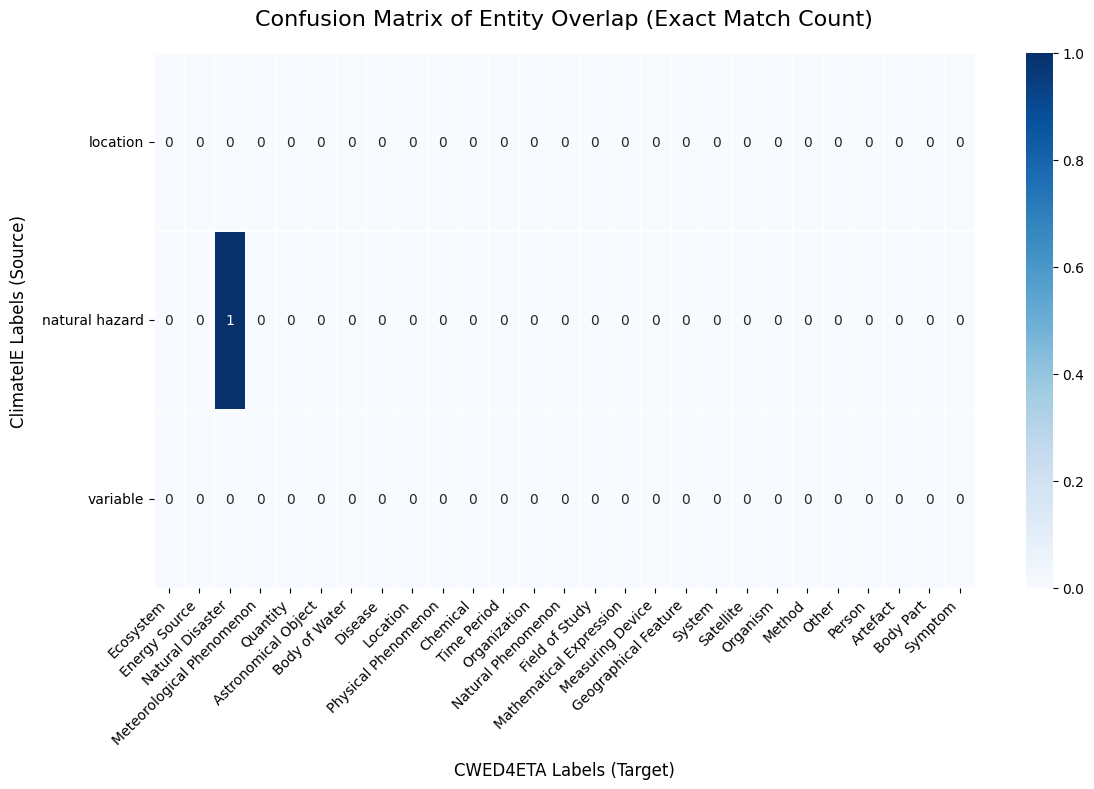

In [8]:

def plot_overlap_confusion_matrix(overlap_results: Dict[str, Dict[str, Set[str]]]):
    """
    Creates and displays a confusion matrix heatmap showing the count of overlapping entities.

    Args:
        overlap_results: The nested dictionary generated by calculate_entity_overlap.
    """
    # Extract the labels for the rows (source) and columns (target)
    source_labels = list(overlap_results.keys())
    # We can get all target labels from the first source label's keys
    target_labels = list(overlap_results[source_labels[0]].keys())
    
    # Create a 2D list (matrix) of the counts of overlapping entities
    counts_matrix = []
    for source_label in source_labels:
        row = [len(overlap_results[source_label][target_label]) for target_label in target_labels]
        counts_matrix.append(row)
        
    # Create a pandas DataFrame from our data
    # This is the standard input format for seaborn heatmaps
    df_confusion_matrix = pd.DataFrame(counts_matrix, index=source_labels, columns=target_labels)

    # --- Plotting ---
    # Set the figure size to ensure labels are readable
    plt.figure(figsize=(12, 8))
    
    # Create the heatmap using seaborn
    heatmap = sns.heatmap(
        df_confusion_matrix, 
        annot=True,     # Write the data value in each cell
        fmt='d',        # Format the numbers as integers
        cmap='Blues',   # Use a blue color palette
        linewidths=.5   # Add lines between cells
    )
    
    # Customize the plot
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=10)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=10)
    
    plt.ylabel('ClimateIE Labels (Source)', fontsize=12, labelpad=10)
    plt.xlabel('CWED4ETA Labels (Target)', fontsize=12, labelpad=10)
    plt.title('Confusion Matrix of Entity Overlap (Exact Match Count)', fontsize=16, pad=20)
    
    plt.tight_layout() # Adjust layout to make room for labels
    plt.show()

# --- 3. Plot the Confusion Matrix ---
# This function creates and displays the visual report
plot_overlap_confusion_matrix(overlap_data)

In [9]:
entities_by_label_ClimateIE
entities_by_label_CWED4ETA

{'Ecosystem': {'Arctic meadows',
  'Artificial water-treatment wetlands',
  'Cloud forest',
  'Deciduous Broadleaf Forest',
  'Deciduous Conifer Forest',
  'Ecosystem',
  'Evergreen Broadleaf Forest',
  'Evergreen Conifer Forest',
  'Forest',
  'Forests',
  'GPE',
  'Genus-Physiognomy-Ecosystem',
  'OEW',
  'Orlando Easterly Wetlands',
  'SAV',
  'Tropical montane cloud forest',
  'Vegetation',
  'agro-ecological zones',
  'animal habitat',
  'aquatic vegetation',
  'biosphere',
  'boreal forests',
  'cattle pasture',
  'closed ecosystem',
  'cloud forests',
  'cypress dome',
  'deep marsh',
  'ecosystem',
  'ecosystems',
  'experimental communities',
  'forest',
  'forest ecosystems',
  'forests',
  'grassland',
  'grasslands',
  'marine ecosystems',
  'mixed marsh',
  'mixed stands',
  'montane biodiversity',
  'plant communities',
  'rookery',
  'shrubland',
  'single-species systems',
  'soil–plant system',
  'submerged aquatic vegetation',
  'terrestrial vegetation',
  'trophic ne

## Calculate Overlap Advanced


--- Running Case-Insensitive Analysis ---


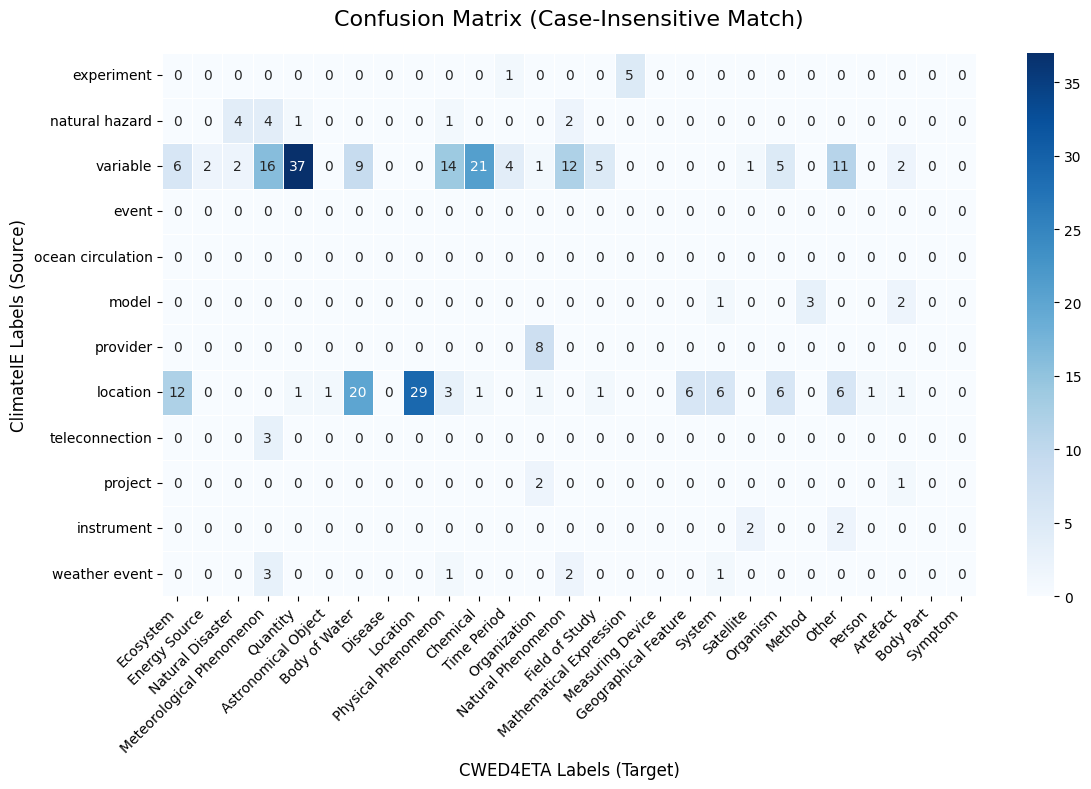


--- Running Case-Insensitive Analysis ---


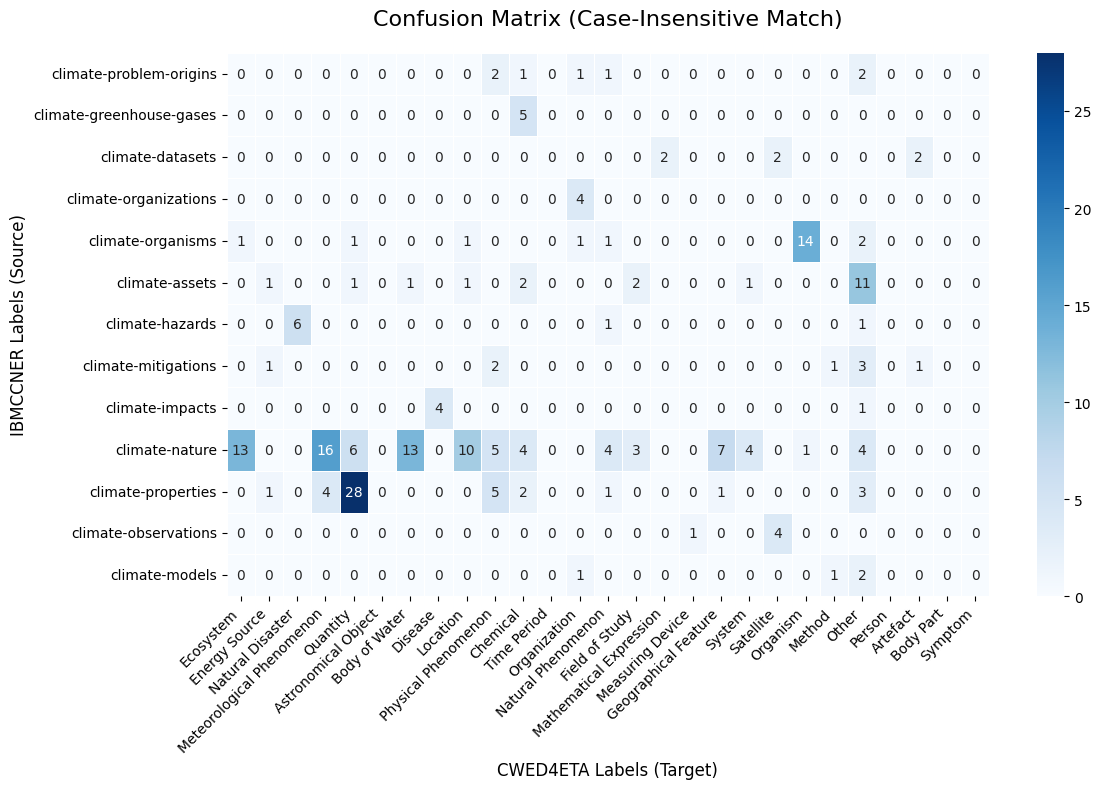


--- Running Case-Insensitive Analysis ---


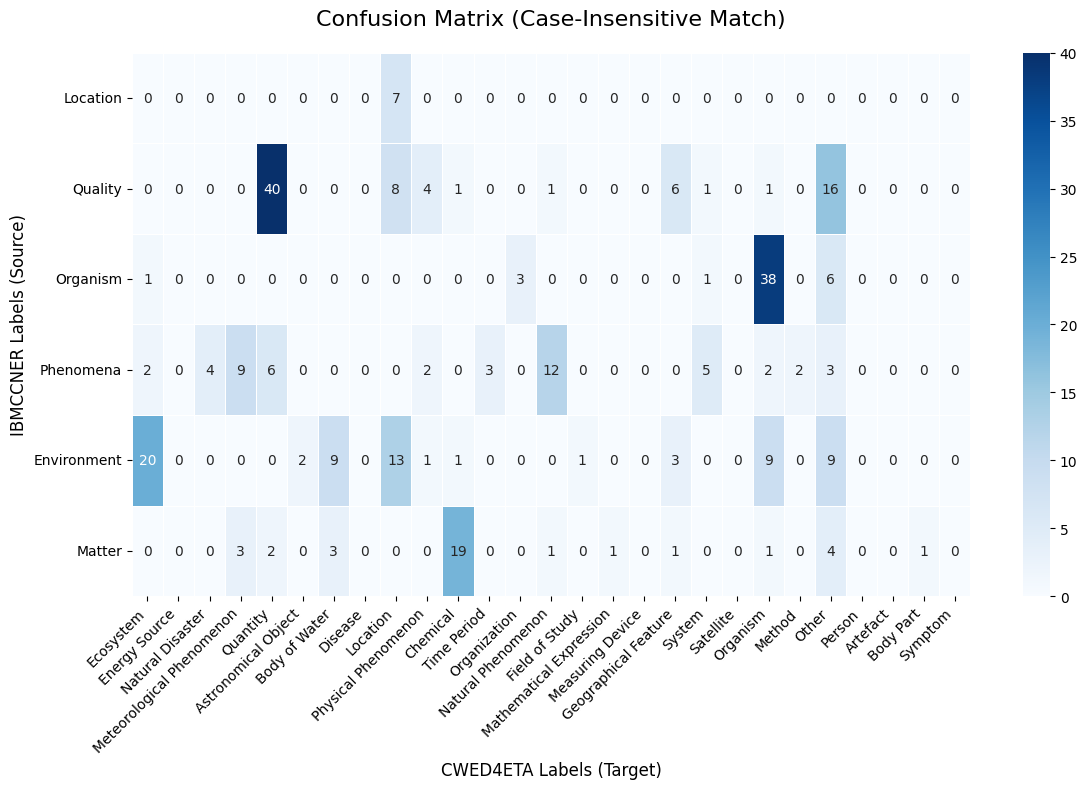

In [23]:
def calculate_entity_overlap(
    source_entities: Dict[str, Set[str]],
    target_entities: Dict[str, Set[str]],
    case_sensitive: bool = True
) -> Dict[str, Dict[str, Set[str]]]:
    """
    Calculates entity overlap between two dictionaries of labeled entities.
    Can perform either a case-sensitive (exact) or case-insensitive match.

    Args:
        source_entities: The first dictionary (e.g., ClimateIE).
                         Format: {'label': {'entity1', 'entity2'}}
        target_entities: The second dictionary (e.g., CWED4ETA) to compare against.
                         Format: {'label': {'entityA', 'entityB'}}
        case_sensitive: If True, performs an exact match ("Africa" != "africa").
                        If False, performs a case-insensitive match ("Africa" == "africa").

    Returns:
        A nested dictionary containing the overlap results. The overlapping entities
        are returned with their original casing from the source_entities dictionary.
        Format: {'source_label': {'target_label': {'overlapping_entity'}}}
    """
    overlap_results = {}

    # Iterate through each label and its set of entities in the source dictionary
    for source_label, source_entity_set in source_entities.items():
        overlap_results[source_label] = {}
        
        # Now, compare with each label and its set of entities in the target dictionary
        for target_label, target_entity_set in target_entities.items():
            
            if case_sensitive:
                # Original logic: fast, case-sensitive set intersection
                common_entities = source_entity_set & target_entity_set
            else:
                # New logic: case-insensitive matching
                # Create a set of lowercase target entities for fast lookups
                target_lower_set = {entity.lower() for entity in target_entity_set}
                
                # Find source entities whose lowercase version exists in the target set
                common_entities = {
                    source_entity for source_entity in source_entity_set 
                    if source_entity.lower() in target_lower_set
                }

            overlap_results[source_label][target_label] = common_entities
            
    return overlap_results

def plot_overlap_confusion_matrix(overlap_results: Dict[str, Dict[str, Set[str]]], title: str, source_name="ClimateIE", target_name="CWED4ETA"):
    """
    Creates and displays a confusion matrix heatmap from the overlap results.
    """
    source_labels = list(overlap_results.keys())
    target_labels = list(overlap_results[source_labels[0]].keys())
    
    counts_matrix = [[len(overlap_results[s_label][t_label]) for t_label in target_labels] for s_label in source_labels]
        
    df_confusion_matrix = pd.DataFrame(counts_matrix, index=source_labels, columns=target_labels)

    plt.figure(figsize=(12, 8))
    heatmap = sns.heatmap(df_confusion_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    
    plt.ylabel(f'{source_name} Labels (Source)', fontsize=12)
    plt.xlabel(f'{target_name} Labels (Target)', fontsize=12)
    plt.title(title, fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.show()


# # --- 2. Run and Plot Case-Sensitive (Exact Match) ---
# print("--- Running Case-Sensitive Analysis (Exact Match) ---")
# exact_overlap_data = calculate_entity_overlap(
#     entities_by_label_ClimateIE,
#     entities_by_label_CWED4ETA,
#     case_sensitive=True  # This is the default
# )
# plot_overlap_confusion_matrix(exact_overlap_data, title='Confusion Matrix (Exact Match)')

# --- 3. Run and Plot Case-Insensitive ---
print("\n--- Running Case-Insensitive Analysis ---")
uncased_overlap_data = calculate_entity_overlap(
    entities_by_label_ClimateIE,
    entities_by_label_CWED4ETA,
    case_sensitive=False # Set to False for case-insensitive matching
)
plot_overlap_confusion_matrix(uncased_overlap_data, title='Confusion Matrix (Case-Insensitive Match)')

print("\n--- Running Case-Insensitive Analysis ---")
uncased_overlap_data = calculate_entity_overlap(
    entities_by_label_IBMCCNER,
    entities_by_label_CWED4ETA,
    case_sensitive=False # Set to False for case-insensitive matching
)
plot_overlap_confusion_matrix(uncased_overlap_data, title='Confusion Matrix (Case-Insensitive Match)', source_name="IBMCCNER")

print("\n--- Running Case-Insensitive Analysis ---")
uncased_overlap_data = calculate_entity_overlap(
    entities_by_label_BIODIVNER,
    entities_by_label_CWED4ETA,
    case_sensitive=False # Set to False for case-insensitive matching
)
plot_overlap_confusion_matrix(uncased_overlap_data, title='Confusion Matrix (Case-Insensitive Match)', source_name="IBMCCNER")

# print("\n--- Running Case-Insensitive Analysis ---")
# uncased_overlap_data = calculate_entity_overlap(
#     entities_by_label_ClimateIE,
#     entities_by_label_IBMCCNER,
#     case_sensitive=False # Set to False for case-insensitive matching
# )
# plot_overlap_confusion_matrix(uncased_overlap_data, title='Confusion Matrix (Case-Insensitive Match)', target_name="IBMCCNER")

## Calculate overal with normalization

In [32]:
def generate_and_save_overlap_matrices(
    source_entities: Dict[str, Set[str]],
    source_name: str,
    target_entities: Dict[str, Set[str]],
    target_name: str,
    case_sensitive: bool = True
):
    """
    Generates and saves a full suite of entity overlap confusion matrices.

    This function creates four plots for the given entity sets:
    1. Raw overlap count.
    2. Row-wise normalization (mapping view).
    3. Column-wise normalization (composition view).
    4. Jaccard similarity.

    All plots are saved to a 'PLOTS' directory with a descriptive filename.

    Args:
        source_entities: The source dictionary of labeled entity sets.
        source_name: The name of the source dataset (e.g., 'ClimateIE').
        target_entities: The target dictionary of labeled entity sets.
        target_name: The name of the target dataset (e.g., 'CWED4ETA').
        case_sensitive: If True, performs exact matching. If False, case-insensitive.
    """
    # Create the output directory if it doesn't exist
    output_dir = 'PLOTS'
    os.makedirs(output_dir, exist_ok=True)
    
    normalization_types = ['count', 'row', 'column', 'jaccard']
    
    # Pre-calculate totals for efficiency
    source_labels = list(source_entities.keys())
    target_labels = list(target_entities.keys())
    target_totals = {label: len(entities) for label, entities in target_entities.items()}

    # --- Loop through each normalization type to create and save a plot ---
    for norm_type in normalization_types:
        print(f"Generating matrix for normalization: '{norm_type}'...")
        
        # --- 1. Calculate the Matrix Data ---
        matrix = []
        for s_label in source_labels:
            row = []
            source_set = source_entities[s_label]
            source_total = len(source_set)
            
            for t_label in target_labels:
                target_set = target_entities[t_label]
                target_total = target_totals[t_label]
                
                # Calculate overlap count
                if case_sensitive:
                    common_entities = source_set & target_set
                else:
                    target_lower_set = {entity.lower() for entity in target_set}
                    common_entities = {s for s in source_set if s.lower() in target_lower_set}
                overlap_count = len(common_entities)
                
                # Apply normalization
                value = 0.0
                if norm_type == 'count': value = overlap_count
                elif norm_type == 'row': value = overlap_count / source_total if source_total > 0 else 0
                elif norm_type == 'column': value = overlap_count / target_total if target_total > 0 else 0
                elif norm_type == 'jaccard':
                    union = source_total + target_total - overlap_count
                    value = overlap_count / union if union > 0 else 0
                row.append(value)
            matrix.append(row)
            
        df_matrix = pd.DataFrame(matrix, index=source_labels, columns=target_labels)

        # --- 2. Plot the Matrix ---
        is_float = norm_type != 'count'
        fmt = '.2f' if is_float else 'd'
        cmap = 'Oranges' if is_float else 'Blues'
        
        # Create a descriptive title
        title = f"Overlap Matrix ({norm_type.replace('_', ' ').title()})\n{source_name} vs {target_name}"
        
        plt.figure(figsize=(12, 10))
        heatmap = sns.heatmap(df_matrix, annot=True, fmt=fmt, cmap=cmap, linewidths=.5)
        
        heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
        heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
        
        plt.ylabel(f'{source_name} Labels', fontsize=12)
        plt.xlabel(f'{target_name} Labels', fontsize=12)
        plt.title(title, fontsize=16, pad=20)
        
        plt.tight_layout()

        # --- 3. Save the Plot ---
        # Create a descriptive filename based on the requested convention
        filename = f"{source_name}_vs_{target_name}_{norm_type}.png"
        save_path = os.path.join(output_dir, filename)
        
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"  -> Plot successfully saved to: {save_path}")
        plt.close() # Close the plot figure to free up memory

# --- Example Usage ---
# Simply call the unified function once.
# It will generate and save all four plot variations.
generate_and_save_overlap_matrices(
    source_entities=entities_by_label_CWED4ETA,
    source_name="CWED4ETA",
    target_entities=entities_by_label_BIODIVNER,
    target_name="BIODIVNER",
    case_sensitive=False
)


Generating matrix for normalization: 'count'...
  -> Plot successfully saved to: PLOTS/CWED4ETA_vs_BIODIVNER_count.png
Generating matrix for normalization: 'row'...
  -> Plot successfully saved to: PLOTS/CWED4ETA_vs_BIODIVNER_row.png
Generating matrix for normalization: 'column'...
  -> Plot successfully saved to: PLOTS/CWED4ETA_vs_BIODIVNER_column.png
Generating matrix for normalization: 'jaccard'...
  -> Plot successfully saved to: PLOTS/CWED4ETA_vs_BIODIVNER_jaccard.png


## Specific Overlap Checks - Single Class

In [7]:
# entities_by_label_BIODIVNER
# entities_by_label_IBMCCNER
# entities_by_label_ClimateIE
# entities_by_label_CWED4ETA
print(entities_by_label_ClimateIE.keys())
print(entities_by_label_ClimateIE["provider"])

dict_keys(['variable', 'provider', 'project', 'natural hazard', 'weather event', 'ocean circulation', 'event', 'model', 'teleconnection', 'location', 'instrument', 'experiment'])
{'COADS', 'Helsinki Commission', 'Deloitte', 'NASA', 'National Center for Atmospheric Research', 'National Oceanic and Atmospheric Administration', 'National Green Tribunal', 'JKPCB', 'Université du Québec Institut National de la Recherche Scientifique', 'National Natural Science Foundation of China', 'CISL', 'NERC', 'NASA Goddard Space Flight Center', 'HadISST', 'Flux Network', 'UNESCO', 'WHRC', 'National Centers for Environmental Prediction-National Center for Atmospheric Research', 'Hadley Centre Sea Ice and Sea Surface Temperature', 'European Centre for Medium Range Weather Forecasts', 'MOHC', 'NNR', 'NCAR', 'Intergovernmental Panel on Climate Change', 'NGT', 'USDA', 'FDA', 'Faculty of Public Administration, University of Ljubljana', 'CRU', "NOAA's co-operative observing stations", 'National Oceanographic 

Checking for "Other" class in other datasets:

In [8]:
def map_ner_class(dataset1, dataset2, class_to_observe):
    """
    Analyzes the mapping of a specific NER class from one dataset to the classes in another dataset.

    Args:
        dataset1 (dict): The first NER dataset, where keys are class labels and values are sets of entities.
        dataset2 (dict): The second NER dataset, with the same structure as dataset1.
        class_to_observe (str): The class label from dataset1 to be analyzed.

    Returns:
        dict: A dictionary containing the mapping results, including percentage distribution
              and the specific entities that map to each class in the second dataset.
              Returns None if the class_to_observe is not in dataset1.
    """
    if class_to_observe not in dataset1:
        print(f"Error: Class '{class_to_observe}' not found in the first dataset.")
        return None

    entities_to_observe = {entity.lower() for entity in dataset1[class_to_observe]}
    total_entities = len(entities_to_observe)
    
    if total_entities == 0:
        print(f"Warning: Class '{class_to_observe}' in the first dataset has no entities.")
        return {"percentage_mapping": {}, "entity_mapping": {}}

    # Create a reverse mapping for dataset2 for efficient lookup
    entity_to_class_map_dataset2 = defaultdict(list)
    for label, entities in dataset2.items():
        for entity in entities:
            entity_to_class_map_dataset2[entity.lower()].append(label)

    class_mapping_counts = defaultdict(int)
    entity_class_mapping = defaultdict(list)

    unmapped_entities = []

    for entity in entities_to_observe:
        if entity in entity_to_class_map_dataset2:
            mapped_classes = entity_to_class_map_dataset2[entity]
            for mapped_class in mapped_classes:
                class_mapping_counts[mapped_class] += 1
                entity_class_mapping[mapped_class].append(entity)
        else:
            unmapped_entities.append(entity)

    # Calculate percentage mapping
    percentage_mapping = {
        class_label: (count / total_entities) * 100
        for class_label, count in class_mapping_counts.items()
    }
    
    if unmapped_entities:
        class_mapping_counts["<unmapped>"] = len(unmapped_entities)
        entity_class_mapping["<unmapped>"] = unmapped_entities
        percentage_mapping["<unmapped>"] = (len(unmapped_entities) / total_entities) * 100


    return {
        "percentage_mapping": percentage_mapping,
        "entity_mapping": entity_class_mapping
    }
    

In [9]:
THRESHOLD = 0.89

mapping = map_ner_class(entities_by_label_CWED4ETA, entities_by_label_BIODIVNER, "Other")
print("BIODIVNER")
for label in dict(sorted(mapping["percentage_mapping"].items(), key=lambda item: item[1], reverse=True)).items():
    print(f"{label[1]:.2f}% - ", label[0])
    if label[1] > THRESHOLD and label[0] != "<unmapped>":
        print(mapping["entity_mapping"][label[0]])
    
mapping = map_ner_class(entities_by_label_CWED4ETA, entities_by_label_IBMCCNER, "Other")
print("IBMCCNER")
for label in dict(sorted(mapping["percentage_mapping"].items(), key=lambda item: item[1], reverse=True)).items():
    print(f"{label[1]:.2f}% - ", label[0])
    if label[1] > THRESHOLD and label[0] != "<unmapped>":
        print(mapping["entity_mapping"][label[0]])
    
mapping = map_ner_class(entities_by_label_CWED4ETA, entities_by_label_ClimateIE, "Other")
print("ClimateIE")
for label in dict(sorted(mapping["percentage_mapping"].items(), key=lambda item: item[1], reverse=True)).items():
    print(f"{label[1]:.2f}% - ", label[0])
    if label[1] > THRESHOLD and label[0] != "<unmapped>":
        print(mapping["entity_mapping"][label[0]])

BIODIVNER
96.69% -  <unmapped>
2.86% -  Quality
['dry', 'chemical composition', 'spatial distribution', 'genus', 'genus', 'genus', 'species', 'land-use', 'energy', 'energy', 'deciduous', 'structure', 'evergreen', 'concentrations', 'dead', 'dead', 'population', 'population', 'soil']
1.50% -  Environment
['communities', 'species', 'atmospheric', 'deciduous', 'evergreen', 'ground', 'community', 'community', 'soil', 'soil']
0.90% -  Organism
['species', 'species', 'species', 'deciduous', 'evergreen', 'community']
0.60% -  Phenomena
0.60% -  Matter
IBMCCNER
95.19% -  <unmapped>
2.41% -  climate-assets
['health', 'health', 'forest management', 'rice', 'life', 'crop', 'crop', 'welfare', 'agricultural', 'energy', 'residential', 'water supply', 'water supply', 'water resources', 'human health', 'homes']
0.90% -  climate-nature
['atmospheric', 'air', 'water resources', 'water resources', 'hydroclimatic', 'soil']
0.60% -  climate-mitigations
0.45% -  climate-organisms
0.45% -  climate-properties


In [60]:
def map_across_ner_classes(dataset1, dataset2 = entities_by_label_CWED4ETA):
    for key in dataset1.keys():
        mapping = map_ner_class(dataset1, dataset2, f"{key}")
        print(key)
        for label in dict(sorted(mapping["percentage_mapping"].items(), key=lambda item: item[1], reverse=True)).items():
            print(f"{label[1]:.2f}% - ", label[0])
        print(10*"---")

map_across_ner_classes(entities_by_label_ClimateIE)

provider
91.87% -  <unmapped>
8.13% -  Organization
------------------------------
model
98.73% -  <unmapped>
0.85% -  Method
0.42% -  Artefact
0.21% -  Location
0.21% -  Meteorological Phenomenon
0.21% -  System
------------------------------
teleconnection
93.15% -  <unmapped>
4.11% -  Meteorological Phenomenon
1.37% -  Quantity
1.37% -  System
------------------------------
weather event
91.89% -  <unmapped>
2.70% -  System
2.70% -  Meteorological Phenomenon
1.35% -  Measuring Device
1.35% -  Method
1.35% -  Quantity
1.35% -  Physical Phenomenon
1.35% -  Natural Disaster
1.35% -  Natural Phenomenon
------------------------------
location
89.77% -  <unmapped>
4.74% -  Location
2.05% -  Body of Water
1.51% -  Ecosystem
1.08% -  Geographical Feature
0.75% -  System
0.54% -  Organism
0.43% -  Other
0.22% -  Chemical
0.22% -  Artefact
0.22% -  Physical Phenomenon
0.11% -  Astronomical Object
0.11% -  Field of Study
0.11% -  Person
0.11% -  Quantity
0.11% -  Organization
-----------------

In [55]:
def map_across_ner_classes_table(dataset1, dataset2):
    """
    Generates a pandas DataFrame summarizing the class mappings.
    """
    mapping_data = []
    
    for key in dataset1.keys():
        mapping = map_ner_class(dataset1, dataset2, key)
        
        for label, percent in mapping["percentage_mapping"].items():
            # Add a row for each mapping
            mapping_data.append({
                'Source Class': key,
                'Target Class': label,
                'Overlap (%)': percent
            })
            
    # Create the DataFrame
    df = pd.DataFrame(mapping_data)
    
    # For better viewing, sort it and set a display option for floats
    pd.options.display.float_format = '{:,.2f}'.format
    df_sorted = df.sort_values(by=['Source Class', 'Overlap (%)'], ascending=[True, False])
    
    return df_sorted

def map_across_ner_classes_pivot(dataset1, dataset2):
    """
    Generates a pivoted DataFrame (a cross-tabulation) for a heatmap-style view.
    """
    # Get the flat table first from the function in Suggestion 2
    df_flat = map_across_ner_classes_table(dataset1, dataset2)
    
    # Pivot the table
    pivot_df = df_flat.pivot_table(
        index='Source Class', 
        columns='Target Class', 
        values='Overlap (%)',
        fill_value=0  # Fill non-existent mappings with 0
    )
    
    return pivot_df

# entities_by_label_BIODIVNER
# entities_by_label_IBMCCNER
# entities_by_label_ClimateIE
# entities_by_label_CWED4ETA
map_across_ner_classes_pivot(entities_by_label_ClimateIE, entities_by_label_CWED4ETA).to_csv("RESULTS/DATASET_OVERLAPS/ClimateIE_CWED4ETA.csv")
map_across_ner_classes_pivot(entities_by_label_IBMCCNER, entities_by_label_CWED4ETA).to_csv("RESULTS/DATASET_OVERLAPS/IBMCCNER_CWED4ETA.csv")
map_across_ner_classes_pivot(entities_by_label_BIODIVNER, entities_by_label_CWED4ETA).to_csv("RESULTS/DATASET_OVERLAPS/BIODIVNER_CWED4ETA.csv")